# Fine-tuning de Modelos Transformer para Deteccion de Cambio de Autor

## 0. Setup e Imports

In [31]:
# Importo todas las librerias necesarias para el fine-tuning
import torch
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments, 
    Trainer,
    DataCollatorWithPadding,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
from datasets import Dataset
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Configuro el estilo de los plots para que se vean bien
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.precision', 4)

In [32]:
# Verifico que todas las librerias necesarias esten instaladas
# Esto es especialmente importante para QLoRA que requiere bitsandbytes y peft

print("="*70)
print("VERIFICACION DE LIBRERIAS Y HARDWARE")
print("="*70)

# Verificar librerias criticas
libraries_status = {}

# bitsandbytes (requerido para QLoRA)
try:
    import bitsandbytes
    libraries_status['bitsandbytes'] = f"✓ {bitsandbytes.__version__}"
except ImportError:
    libraries_status['bitsandbytes'] = "✗ NO INSTALADO - Instalar con: pip install bitsandbytes"

# peft (requerido para LoRA/QLoRA)
try:
    import peft
    libraries_status['peft'] = f"✓ {peft.__version__}"
except ImportError:
    libraries_status['peft'] = "✗ NO INSTALADO - Instalar con: pip install peft"

# accelerate (recomendado para optimizacion)
try:
    import accelerate
    libraries_status['accelerate'] = f"✓ {accelerate.__version__}"
except ImportError:
    libraries_status['accelerate'] = "✗ NO INSTALADO - Instalar con: pip install accelerate"

# transformers
try:
    import transformers
    libraries_status['transformers'] = f"✓ {transformers.__version__}"
except ImportError:
    libraries_status['transformers'] = "✗ NO INSTALADO"

print("\nEstado de librerias:")
for lib, status in libraries_status.items():
    print(f"  {lib:20s}: {status}")

# Verificar CUDA y GPU
print("\nHardware:")
cuda_available = torch.cuda.is_available()
print(f"  CUDA disponible: {cuda_available}")

if cuda_available:
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  VRAM total: {vram_total:.1f} GB")
    torch.cuda.empty_cache()
    vram_free = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1e9
    print(f"  VRAM libre: {vram_free:.1f} GB")
    
    # Advertencias segun VRAM disponible
    if vram_total < 16:
        print(f"\n  ADVERTENCIA: VRAM insuficiente ({vram_total:.1f} GB).")
        print(f"  Se recomienda 16GB+ para entrenar modelos grandes con QLoRA.")
    else:
        print(f"\n  ✓ VRAM suficiente para QLoRA con modelos de 8B parametros.")
else:
    print("\n  ERROR: No se detecto GPU. El entrenamiento requiere GPU con CUDA.")

print("="*70)

VERIFICACION DE LIBRERIAS Y HARDWARE

Estado de librerias:
  bitsandbytes        : ✓ 0.49.0
  peft                : ✓ 0.12.0
  accelerate          : ✓ 1.12.0
  transformers        : ✓ 4.57.3

Hardware:
  CUDA disponible: True
  GPU: NVIDIA GeForce RTX 5070 Ti
  VRAM total: 17.1 GB
  VRAM libre: 11.8 GB

  ✓ VRAM suficiente para QLoRA con modelos de 8B parametros.


In [33]:
# Verificacion de hardware movida a la celda anterior (mas completa)
print("Verificacion de hardware completada en celda anterior.")

Verificacion de hardware completada en celda anterior.


In [34]:
# Defino las rutas del proyecto
# Necesito encontrar la raiz del proyecto para acceder a los datos y guardar checkpoints

def find_root() -> Path:
    """Busco la raiz del proyecto localizando el directorio data/raw."""
    current = Path.cwd()
    for cand in [current, *current.parents]:
        if (cand / "data" / "raw").exists():
            return cand
    raise FileNotFoundError("No se encontro data/raw desde el directorio actual.")

# Establezco todas las rutas que voy a necesitar
PROJECT_ROOT = find_root()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
BOUNDARIES_DIR = DATA_PROCESSED / "boundaries"
REPORTS_DIR = PROJECT_ROOT / "reports"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints" / "finetuning"
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"BOUNDARIES_DIR: {BOUNDARIES_DIR}")
print(f"CHECKPOINTS_DIR: {CHECKPOINTS_DIR}")
print(f"REPORTS_DIR: {REPORTS_DIR}")

PROJECT_ROOT: /home/eeguskiza/DEUSTO/multi-author-analysis
BOUNDARIES_DIR: /home/eeguskiza/DEUSTO/multi-author-analysis/data/processed/boundaries
CHECKPOINTS_DIR: /home/eeguskiza/DEUSTO/multi-author-analysis/checkpoints/finetuning
REPORTS_DIR: /home/eeguskiza/DEUSTO/multi-author-analysis/reports


## 1. Configuracion Global

In [35]:
# Configuracion global del experimento
# Aqui defino todos los parametros importantes para el fine-tuning

SEED = 42
MAX_LENGTH = 128  # Tokens maximos por par de oraciones

# Configuracion especifica por modelo
# Cada modelo tiene sus propios hyperparametros optimizados
CONFIGS = {
    "deberta-v3-large": {
        "model_name": "microsoft/deberta-v3-large",
        "batch_size": 4,  # Reducido para 16GB VRAM
        "gradient_accumulation_steps": 4,  # Simula batch_size=16
        "learning_rate": 1e-5,  # DeBERTa requiere LRs bajos
        "epochs": 3,
        "use_qlora": False,  # Full fine-tuning (intentar primero, si OOM -> LoRA)
        "description": "304M params - Full fine-tuning (encoder SOTA)"
    },
    "llama-3.1-8b": {
        "model_name": "meta-llama/Meta-Llama-3.1-8B-Instruct",
        "batch_size": 2,  # Muy reducido para QLoRA con modelo grande
        "gradient_accumulation_steps": 8,  # Simula batch_size=16
        "learning_rate": 2e-4,  # Mayor LR para LoRA
        "epochs": 3,
        "use_qlora": True,  # QLoRA obligatorio (4-bit quantization)
        "lora_r": 64,  # Mayor rank para capturar matices de estilo
        "lora_alpha": 128,  # Alpha = 2 * r
        "lora_dropout": 0.1,
        "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        "description": "8B params - QLoRA (4-bit, decoder SOTA)"
    },
}

# Para entrenar solo algunos modelos, comentar los que no quieras
MODELS_TO_TRAIN = ["deberta-v3-large", "llama-3.1-8b"]

# Muestro la configuracion
print("="*70)
print("CONFIGURACION DEL EXPERIMENTO")
print("="*70)
print(f"\nSEED: {SEED}")
print(f"MAX_LENGTH: {MAX_LENGTH} tokens")
print(f"\nModelos a entrenar: {len(MODELS_TO_TRAIN)}")
for model_key in MODELS_TO_TRAIN:
    config = CONFIGS[model_key]
    print(f"\n  {model_key}:")
    print(f"    {config['description']}")
    print(f"    Batch size: {config['batch_size']} (effective: {config['batch_size'] * config.get('gradient_accumulation_steps', 1)})")
    print(f"    Learning rate: {config['learning_rate']}")
    print(f"    Epochs: {config['epochs']}")
    if config.get('use_qlora'):
        print(f"    QLoRA: r={config.get('lora_r')}, alpha={config.get('lora_alpha')}")
print("="*70)

CONFIGURACION DEL EXPERIMENTO

SEED: 42
MAX_LENGTH: 128 tokens

Modelos a entrenar: 2

  deberta-v3-large:
    304M params - Full fine-tuning (encoder SOTA)
    Batch size: 4 (effective: 16)
    Learning rate: 1e-05
    Epochs: 3

  llama-3.1-8b:
    8B params - QLoRA (4-bit, decoder SOTA)
    Batch size: 2 (effective: 16)
    Learning rate: 0.0002
    Epochs: 3
    QLoRA: r=64, alpha=128


## 2. Carga de Datos y Creacion del Dataset

In [36]:
# Funcion para cargar oraciones desde los archivos raw
# Cada documento tiene una oracion por linea en los archivos .txt

def load_sentences(level: str, split: str, doc_id: str) -> list[str]:
    """Carga las oraciones de un documento desde el archivo raw.
    
    Args:
        level: 'easy', 'medium', o 'hard'
        split: 'train' o 'validation'
        doc_id: ID del documento (ej: 'problem-1')
        
    Returns:
        list[str]: Lista de oraciones del documento
    """
    path = DATA_RAW / level / split / f"{doc_id}.txt"
    
    if not path.exists():
        raise FileNotFoundError(f"No se encontro el archivo: {path}")
    
    # Leer y dividir por lineas (cada linea es una oracion)
    text = path.read_text(encoding='utf-8').strip()
    sentences = text.split('\n')
    
    # Filtrar lineas vacias
    sentences = [s.strip() for s in sentences if s.strip()]
    
    return sentences

print("Funcion load_sentences() definida.")

Funcion load_sentences() definida.


In [37]:
# Cargo los datasets de boundaries (pares de oraciones consecutivas con etiquetas)
# Cada fila contiene level, doc_id, sent_left_id, sent_right_id, y (0=mismo autor, 1=cambio)

print("Cargando boundaries...")
boundaries_train = pd.read_csv(BOUNDARIES_DIR / "boundaries_train.csv")
boundaries_val = pd.read_csv(BOUNDARIES_DIR / "boundaries_validation.csv")

print(f"\nTrain: {len(boundaries_train):,} boundaries")
print(f"Val: {len(boundaries_val):,} boundaries")

print(f"\nDistribucion train:")
print(boundaries_train['y'].value_counts())
print(f"  Clase 0 (mismo autor): {(boundaries_train['y'] == 0).mean():.1%}")
print(f"  Clase 1 (cambio):      {(boundaries_train['y'] == 1).mean():.1%}")

print(f"\nDistribucion validation:")
print(boundaries_val['y'].value_counts())
print(f"  Clase 0 (mismo autor): {(boundaries_val['y'] == 0).mean():.1%}")
print(f"  Clase 1 (cambio):      {(boundaries_val['y'] == 1).mean():.1%}")

print(f"\nDistribucion por nivel en validation:")
print(boundaries_val['level'].value_counts())

Cargando boundaries...

Train: 159,002 boundaries
Val: 33,858 boundaries

Distribucion train:
y
0    128708
1     30294
Name: count, dtype: int64
  Clase 0 (mismo autor): 80.9%
  Clase 1 (cambio):      19.1%

Distribucion validation:
y
0    27290
1     6568
Name: count, dtype: int64
  Clase 0 (mismo autor): 80.6%
  Clase 1 (cambio):      19.4%

Distribucion por nivel en validation:
level
medium    12863
hard      10749
easy      10246
Name: count, dtype: int64


In [38]:
# Funcion para crear pares de texto (sent_a, sent_b, label) desde el DataFrame de boundaries
# Esto es necesario para crear el Dataset de HuggingFace

def create_text_pairs(df: pd.DataFrame, desc: str = "Creando pares") -> list[dict]:
    """Crea lista de {text_a, text_b, label, level, doc_id} para el dataset.
    
    Args:
        df: DataFrame con boundaries (level, split, doc_id, sent_left_id, sent_right_id, y)
        desc: Descripcion para tqdm
        
    Returns:
        list[dict]: Lista de diccionarios con pares de oraciones y labels
    """
    pairs = []
    skipped = 0
    
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        try:
            # Cargar oraciones del documento
            sentences = load_sentences(row['level'], row['split'], row['doc_id'])
            
            # Validar que los indices existan
            if row['sent_left_id'] >= len(sentences) or row['sent_right_id'] >= len(sentences):
                skipped += 1
                continue
            
            # Obtener las dos oraciones
            text_a = sentences[row['sent_left_id']]
            text_b = sentences[row['sent_right_id']]
            
            # Validar que no esten vacias
            if not text_a or not text_b:
                skipped += 1
                continue
            
            # Anadir el par al dataset
            pairs.append({
                'text_a': text_a,
                'text_b': text_b,
                'label': int(row['y']),
                'level': row['level'],
                'doc_id': row['doc_id']
            })
            
        except Exception as e:
            skipped += 1
            if skipped <= 5:  # Mostrar solo los primeros errores
                print(f"\nError en {row['doc_id']}: {e}")
    
    if skipped > 0:
        print(f"\nSe saltaron {skipped} ejemplos por errores o indices invalidos")
    
    return pairs

print("Funcion create_text_pairs() definida.")

Funcion create_text_pairs() definida.


In [39]:
# Creo los datasets de HuggingFace para entrenamiento y validacion
# Este proceso tarda 5-10 minutos porque tiene que leer ~193k archivos

print("="*70)
print("CREANDO DATASETS")
print("="*70)

# Crear pares de texto para entrenamiento
train_pairs = create_text_pairs(boundaries_train, desc="Creando pares de entrenamiento")
print(f"\n  Pares de entrenamiento validos: {len(train_pairs):,}")

# Crear pares de texto para validacion
val_pairs = create_text_pairs(boundaries_val, desc="Creando pares de validacion")
print(f"\n  Pares de validacion validos: {len(val_pairs):,}")

# Convertir a HuggingFace Dataset
print("\nConvirtiendo a HuggingFace Dataset...")
train_dataset = Dataset.from_list(train_pairs)
val_dataset = Dataset.from_list(val_pairs)

print("\nDatasets creados exitosamente")
print(f"\nTrain dataset: {len(train_dataset):,} ejemplos")
print(f"Val dataset: {len(val_dataset):,} ejemplos")
print("\nColumnas:", train_dataset.column_names)
print("\nEjemplo:")
print(train_dataset[0])
print("="*70)

CREANDO DATASETS


Creando pares de entrenamiento:   0%|          | 0/159002 [00:00<?, ?it/s]


Se saltaron 2307 ejemplos por errores o indices invalidos

  Pares de entrenamiento validos: 156,695


Creando pares de validacion:   0%|          | 0/33858 [00:00<?, ?it/s]


Se saltaron 560 ejemplos por errores o indices invalidos

  Pares de validacion validos: 33,298

Convirtiendo a HuggingFace Dataset...

Datasets creados exitosamente

Train dataset: 156,695 ejemplos
Val dataset: 33,298 ejemplos

Columnas: ['text_a', 'text_b', 'label', 'level', 'doc_id']

Ejemplo:
{'text_a': 'There\'s also incidents of "testosterone insensitive males" that have either ambiguous genitals or are phenotypically female.', 'text_b': 'Female is the human "default" body plan so a number of conditions exist that cause female-looking males.', 'label': 0, 'level': 'easy', 'doc_id': 'problem-1'}


## 3. Funciones de Metricas

In [40]:
# Funciones para calcular metricas de clasificacion
# Estas funciones seran usadas por el Trainer de HuggingFace

def compute_metrics(eval_pred):
    """Funcion de metricas para HuggingFace Trainer.
    
    Args:
        eval_pred: Tupla (logits, labels) del Trainer
        
    Returns:
        dict: Diccionario con metricas calculadas
    """
    predictions, labels = eval_pred
    
    # Obtener predicciones (clase con mayor probabilidad)
    predictions = np.argmax(predictions, axis=1)
    
    # Calcular metricas de clasificacion
    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro', zero_division=0)
    f1_class1 = f1_score(labels, predictions, average='binary', zero_division=0)  # F1 de clase 1 (cambio)
    precision_macro = precision_score(labels, predictions, average='macro', zero_division=0)
    recall_macro = recall_score(labels, predictions, average='macro', zero_division=0)
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_class1': f1_class1,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
    }

print("Funcion compute_metrics() definida.")

Funcion compute_metrics() definida.


## 4. Funciones de Tokenizacion

In [41]:
# Funcion para guardar modelos de forma robusta
# Diferencia entre full fine-tuning (guardar modelo completo) y QLoRA (guardar solo adaptadores)

def save_final_model(trainer, model, tokenizer, save_path: Path, use_qlora: bool, model_key: str):
    """Guarda el modelo entrenado de forma robusta.
    
    Para full fine-tuning: Guarda el modelo completo
    Para QLoRA: Guarda solo los adaptadores LoRA (mas eficiente)
    
    Args:
        trainer: Trainer de HuggingFace
        model: Modelo entrenado
        tokenizer: Tokenizer asociado
        save_path: Ruta donde guardar
        use_qlora: Si True, guarda solo adaptadores LoRA
        model_key: Clave del modelo (para logging)
    """
    save_path.mkdir(parents=True, exist_ok=True)
    
    if use_qlora:
        # Para QLoRA: Guardar solo adaptadores (PeftModel)
        # Esto ahorra mucho espacio (adaptadores ~50-200MB vs modelo completo 15GB+)
        print(f"\n   Guardando adaptadores LoRA en {save_path}...")
        model.save_pretrained(str(save_path))
        
        # Guardar también el tokenizer
        tokenizer.save_pretrained(str(save_path))
        
        # Guardar archivo de configuración indicando modelo base
        config_info = {
            "model_type": "qlora",
            "base_model": CONFIGS[model_key]["model_name"],
            "lora_r": CONFIGS[model_key].get("lora_r"),
            "lora_alpha": CONFIGS[model_key].get("lora_alpha"),
            "target_modules": CONFIGS[model_key].get("target_modules"),
        }
        
        with open(save_path / "adapter_config_info.json", "w") as f:
            json.dump(config_info, f, indent=2)
        
        print(f"   Adaptadores LoRA guardados correctamente")
        
    else:
        # Para full fine-tuning: Guardar modelo completo
        print(f"\n   Guardando modelo completo en {save_path}...")
        trainer.save_model(str(save_path))
        tokenizer.save_pretrained(str(save_path))
        print(f"   Modelo completo guardado correctamente")
    
    # Calcular y mostrar tamaño del checkpoint
    total_size = sum(f.stat().st_size for f in save_path.rglob('*') if f.is_file())
    print(f"   Tamaño del checkpoint: {total_size / 1e6:.1f} MB")

print("Funcion save_final_model() definida.")

Funcion save_final_model() definida.


In [42]:
# Funciones de tokenizacion adaptadas al tipo de modelo
# Los modelos encoder (BERT) y decoder (Qwen, Llama) necesitan formatos diferentes

def get_tokenize_function(tokenizer, max_length: int = MAX_LENGTH):
    """Devuelve funcion de tokenizacion para modelos encoder (BERT-like).
    
    Args:
        tokenizer: Tokenizer de HuggingFace
        max_length: Longitud maxima en tokens
        
    Returns:
        function: Funcion de tokenizacion para dataset.map()
    """
    def tokenize_function(examples):
        # Para modelos encoder (BERT, DeBERTa, etc.)
        # Formato: [CLS] text_a [SEP] text_b [SEP]
        return tokenizer(
            examples['text_a'],
            examples['text_b'],
            truncation=True,
            max_length=max_length,
            padding=False,  # DataCollator se encarga del padding
        )
    return tokenize_function


def get_tokenize_function_causal(tokenizer, max_length: int = MAX_LENGTH, use_instructive_prompt: bool = False):
    """Tokenizacion para modelos causales (Qwen, Llama, etc.).
    
    Concatena las oraciones con separadores explicitos o formato instructivo.
    
    Args:
        tokenizer: Tokenizer de HuggingFace
        max_length: Longitud maxima en tokens
        use_instructive_prompt: Si True, usa formato instructivo para Llama (analisis de estilo)
        
    Returns:
        function: Funcion de tokenizacion para dataset.map()
    """
    def tokenize_function(examples):
        if use_instructive_prompt:
            # Formato instructivo para Llama (analisis de estilo)
            # Este formato aprovecha mejor las capacidades de seguimiento de instrucciones
            texts = [
                f"Analyze the writing style of these two consecutive sentences and determine if they were written by the same author.\n\n"
                f"Text A: {a}\n"
                f"Text B: {b}\n\n"
                f"Are these sentences from the same author?"
                for a, b in zip(examples['text_a'], examples['text_b'])
            ]
        else:
            # Formato simple para modelos causales genericos
            texts = [
                f"Sentence A: {a}\nSentence B: {b}"
                for a, b in zip(examples['text_a'], examples['text_b'])
            ]
        
        return tokenizer(
            texts,
            truncation=True,
            max_length=max_length,
            padding=False,
        )
    return tokenize_function

print("Funciones de tokenizacion definidas.")

Funciones de tokenizacion definidas.


## 5. Funcion de Entrenamiento Generica

In [13]:
# Funcion generica para entrenar cualquier modelo de la configuracion
# Soporta tanto full fine-tuning como QLoRA (4-bit) automaticamente

def train_model(
    model_key: str,
    train_dataset: Dataset,
    val_dataset: Dataset,
    output_dir: Path,
    max_steps: int = None,
    warmup_steps: int = None,
    eval_steps: int = 500,
    save_steps: int = None,
) -> dict:
    """
    Entrena un modelo y devuelve metricas.
    
    Args:
        model_key: Clave en CONFIGS (e.g., "deberta-v3-large", "llama-3.1-8b")
        train_dataset: Dataset de entrenamiento
        val_dataset: Dataset de validacion
        output_dir: Directorio para guardar checkpoints
        max_steps: Si se proporciona, usa max_steps en vez de num_train_epochs
        warmup_steps: Si se proporciona, usa warmup_steps en vez de warmup_ratio
        eval_steps: Frecuencia de evaluacion (default: 500)
        save_steps: Frecuencia de guardado de checkpoints (default: igual a eval_steps)
    
    Returns:
        dict con metricas y configuracion del modelo
    """
    # Obtener configuracion del modelo
    config = CONFIGS[model_key]
    model_name = config["model_name"]
    use_qlora = config.get("use_qlora", False)
    
    # Si no se especifica save_steps, usar el mismo valor que eval_steps
    if save_steps is None:
        save_steps = eval_steps
    
    print(f"\n{'='*70}")
    print(f"ENTRENANDO: {model_key}")
    print(f"{'='*70}")
    print(f"  Modelo base: {model_name}")
    print(f"  {config['description']}")
    print(f"  QLoRA: {use_qlora}")
    print(f"  Batch size: {config['batch_size']} (effective: {config['batch_size'] * config.get('gradient_accumulation_steps', 1)})")
    print(f"  Learning rate: {config['learning_rate']}")
    if max_steps:
        print(f"  Max steps: {max_steps}")
    else:
        print(f"  Epochs: {config['epochs']}")
    
    # Limpiar VRAM antes de empezar
    torch.cuda.empty_cache()
    
    # 1. Cargar tokenizer
    print("\n[1/6] Cargando tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    
    # Manejo especial de pad_token para Llama (asignar eos_token)
    if tokenizer.pad_token is None:
        if "llama" in model_name.lower():
            # Para Llama, crear un nuevo token de padding para no confundir con eos
            tokenizer.add_special_tokens({'pad_token': '<|pad|>'})
            print("   Pad token creado para Llama: '<|pad|>'")
        else:
            tokenizer.pad_token = tokenizer.eos_token
            print(f"   Pad token asignado: {tokenizer.pad_token}")
    
    # 2. Determinar si es modelo causal (decoder) o encoder
    is_causal = "llama" in model_name.lower() or "gpt" in model_name.lower()
    is_llama = "llama" in model_name.lower()
    print(f"   Tipo de modelo: {'Causal (Decoder)' if is_causal else 'Encoder'}")
    
    # 3. Cargar modelo
    print("\n[2/6] Cargando modelo...")
    if use_qlora:
        # Configuracion 4-bit para QLoRA
        # Esto reduce la VRAM necesaria de ~16GB a ~5-6GB para modelos grandes
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_use_double_quant=True,
        )
        
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=2,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
        )
        
        # Resize token embeddings si se añadió pad_token
        if is_llama and len(tokenizer) > model.config.vocab_size:
            model.resize_token_embeddings(len(tokenizer))
            print(f"   Token embeddings redimensionados a {len(tokenizer)}")
        
        # Preparar para k-bit training
        model = prepare_model_for_kbit_training(model)
        
        # Configurar LoRA con target_modules del config
        target_modules = config.get("target_modules", ["q_proj", "v_proj"])
        
        lora_config = LoraConfig(
            r=config.get("lora_r", 16),
            lora_alpha=config.get("lora_alpha", 32),
            lora_dropout=config.get("lora_dropout", 0.05),
            bias="none",
            task_type=TaskType.SEQ_CLS,
            target_modules=target_modules,
        )
        
        model = get_peft_model(model, lora_config)
        print("\n   Parametros entrenables con LoRA:")
        model.print_trainable_parameters()
        
    else:
        # Full fine-tuning - entrenar todos los parametros
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=2,
            trust_remote_code=True,
        )
        
        # Resize token embeddings si se añadió pad_token
        if is_llama and len(tokenizer) > model.config.vocab_size:
            model.resize_token_embeddings(len(tokenizer))
            print(f"   Token embeddings redimensionados a {len(tokenizer)}")
        
        model.to("cuda")
        print(f"   Parametros totales: {sum(p.numel() for p in model.parameters()):,}")
        print(f"   Parametros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    
    # Configurar pad_token_id en el modelo
    if model.config.pad_token_id is None:
        model.config.pad_token_id = tokenizer.pad_token_id
    
    # 4. Tokenizar datasets
    print("\n[3/6] Tokenizando datasets...")
    # Usar prompt instructivo para Llama
    use_instructive = is_llama
    tokenize_fn = (get_tokenize_function_causal(tokenizer, use_instructive_prompt=use_instructive) 
                   if is_causal 
                   else get_tokenize_function(tokenizer))
    
    if use_instructive:
        print("   Usando prompt instructivo para analisis de estilo")
    
    train_tokenized = train_dataset.map(
        tokenize_fn, 
        batched=True, 
        remove_columns=['text_a', 'text_b'],  # Mantengo level y doc_id para analisis posterior
        desc="Tokenizando train"
    )
    val_tokenized = val_dataset.map(
        tokenize_fn, 
        batched=True, 
        remove_columns=['text_a', 'text_b'],
        desc="Tokenizando val"
    )
    
    print(f"   Train tokenizado: {len(train_tokenized):,} ejemplos")
    print(f"   Val tokenizado: {len(val_tokenized):,} ejemplos")
    
    # 5. Data collator para padding dinamico
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    # 6. Training arguments
    print("\n[4/6] Configurando entrenamiento...")
    gradient_accumulation_steps = config.get('gradient_accumulation_steps', 1)
    
    # Calcular steps totales si se usa num_train_epochs
    if not max_steps:
        total_train_steps = (len(train_tokenized) // (config['batch_size'] * gradient_accumulation_steps)) * config['epochs']
    else:
        total_train_steps = max_steps
    
    # Configurar warmup
    if warmup_steps is not None:
        warmup_config = {"warmup_steps": warmup_steps}
        print(f"   Warmup steps: {warmup_steps}")
    else:
        warmup_config = {"warmup_ratio": 0.1}
        print(f"   Warmup ratio: 0.1")

    training_args = TrainingArguments(
        output_dir=str(output_dir / model_key),
        max_steps=max_steps if max_steps else -1,  # -1 significa usar num_train_epochs
        num_train_epochs=config['epochs'] if not max_steps else 1,  # Si max_steps, epochs no importa
        per_device_train_batch_size=config['batch_size'],
        per_device_eval_batch_size=config['batch_size'] * 2,
        gradient_accumulation_steps=gradient_accumulation_steps,
        learning_rate=config['learning_rate'],
        weight_decay=0.01,
        eval_strategy="steps",
        eval_steps=eval_steps,
        save_strategy="steps",
        save_steps=save_steps,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        logging_steps=100,
        **warmup_config,  # warmup_steps o warmup_ratio
        fp16=not use_qlora,  # bf16 con QLoRA, fp16 con full fine-tuning
        bf16=use_qlora,
        report_to="none",  # Desactivar wandb/tensorboard
        seed=SEED,
        save_total_limit=2,  # Mantener solo 2 checkpoints para ahorrar espacio
    )
    
    print(f"   Gradient accumulation steps: {gradient_accumulation_steps}")
    print(f"   Effective batch size: {config['batch_size'] * gradient_accumulation_steps}")
    print(f"   Evaluation strategy: steps (every {eval_steps} steps)")
    print(f"   Save strategy: steps (every {save_steps} steps)")
    print(f"   Total training steps: {total_train_steps}, Evaluations: ~{total_train_steps // eval_steps}")
    
    # 7. Crear Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    
    # 8. Entrenar
    print("\n[5/6] Iniciando entrenamiento...")
    print(f"   Total de pasos de optimizacion: {total_train_steps}")
    print("="*70)
    
    train_result = trainer.train()
    
    # 9. Evaluar
    print("\n[6/6] Evaluando en validacion...")
    eval_result = trainer.evaluate()
    
    # 10. Guardar modelo (llamar a save_final_model)
    best_model_path = output_dir / model_key / "best_model"
    save_final_model(trainer, model, tokenizer, best_model_path, use_qlora, model_key)
    
    # Limpiar VRAM
    del model
    del trainer
    torch.cuda.empty_cache()
    
    return {
        'model_key': model_key,
        'train_loss': train_result.training_loss,
        'eval_metrics': eval_result,
        'config': config,
    }

print("Funcion train_model() definida.")

Funcion train_model() definida.


## 6. Funciones para Mostrar Resultados

In [14]:
# Funciones para mostrar y guardar resultados de entrenamiento

def display_training_results(result: dict):
    """Muestra tabla detallada de resultados de entrenamiento.
    
    Args:
        result: Diccionario con resultados del entrenamiento
    """
    print(f"\n{'='*70}")
    print(f"RESULTADOS DETALLADOS: {result['model_key']}")
    print(f"{'='*70}")
    
    metrics = result['eval_metrics']
    
    # Tabla de metricas
    table = pd.DataFrame({
        'Metrica': ['F1 Macro', 'Accuracy', 'Precision (macro)', 'Recall (macro)', 
                    'F1 Clase 1 (cambio)', 'Eval Loss', 'Train Loss'],
        'Valor': [
            f"{metrics['eval_f1_macro']:.4f}",
            f"{metrics['eval_accuracy']:.4f}",
            f"{metrics['eval_precision_macro']:.4f}",
            f"{metrics['eval_recall_macro']:.4f}",
            f"{metrics['eval_f1_class1']:.4f}",
            f"{metrics['eval_loss']:.4f}",
            f"{result['train_loss']:.4f}",
        ]
    })
    print("\n" + table.to_string(index=False))
    
    # Comparacion con referencias
    print(f"\n{'-'*70}")
    print("COMPARACION CON REFERENCIAS:")
    print(f"{'-'*70}")
    bert_cnn_f1 = 0.707
    qwen_icl_f1 = 0.383  # Mejor ICL del notebook 11
    
    print(f"  E3 bert_cnn (frozen):     F1 = {bert_cnn_f1:.3f}")
    print(f"  ICL qwen3:1.7b (5-shot):  F1 = {qwen_icl_f1:.3f}")
    print(f"  {result['model_key']:20s}  F1 = {metrics['eval_f1_macro']:.3f}")
    
    delta_e3 = metrics['eval_f1_macro'] - bert_cnn_f1
    delta_icl = metrics['eval_f1_macro'] - qwen_icl_f1
    
    print(f"\n  Delta vs E3 (bert_cnn):  {delta_e3:+.3f} ({delta_e3/bert_cnn_f1*100:+.1f}%)")
    print(f"  Delta vs ICL:            {delta_icl:+.3f} ({delta_icl/qwen_icl_f1*100:+.1f}%)")
    
    if metrics['eval_f1_macro'] > bert_cnn_f1:
        print(f"\n  SUPERA A E3 bert_cnn")
    
    print(f"{'='*70}\n")


def save_incremental_results(results: dict, path: Path):
    """Guarda resultados incrementales.
    
    Args:
        results: Diccionario con resultados de todos los modelos
        path: Ruta donde guardar el JSON
    """
    to_save = {}
    for model_key, result in results.items():
        to_save[model_key] = {
            'eval_metrics': result['eval_metrics'],
            'train_loss': result['train_loss'],
            'config': result['config'],
        }
    
    with open(path, 'w') as f:
        json.dump(to_save, f, indent=2, default=str)
    
    print(f"  Resultados guardados en {path.name}")

print("Funciones de visualizacion definidas.")

Funciones de visualizacion definidas.


In [15]:
# Inicializo el diccionario donde guardare los resultados de todos los modelos
# IMPORTANTE: Ejecutar esta celda UNA VEZ antes de entrenar modelos
# Si ya has entrenado algunos modelos y quieres continuar, NO ejecutes esta celda

all_results = {}

print("="*70)
print("DICCIONARIO DE RESULTADOS INICIALIZADO")
print("="*70)
print("\nAhora ejecuta las celdas de entrenamiento de cada modelo.")
print("   Puedes ejecutarlas todas seguidas o una a una.")
print("\nIMPORTANTE: Si ya has entrenado algunos modelos y quieres continuar,")
print("   NO ejecutes esta celda (perderias los resultados).")
print("="*70)

DICCIONARIO DE RESULTADOS INICIALIZADO

Ahora ejecuta las celdas de entrenamiento de cada modelo.
   Puedes ejecutarlas todas seguidas o una a una.

IMPORTANTE: Si ya has entrenado algunos modelos y quieres continuar,
   NO ejecutes esta celda (perderias los resultados).


## 7. Entrenamiento por Modelo (celdas separadas)

**Instrucciones:**
- Cada celda entrena un modelo independientemente
- Puedes ejecutar todas seguidas (tarda varias horas) o una a una
- Los resultados se guardan incrementalmente despues de cada modelo
- Los checkpoints se guardan en `checkpoints/finetuning/{model_key}/`

### 7.1 DeBERTa-v3-Large (304M params)

In [16]:
# Entreno DeBERTa-v3-Large con full fine-tuning
# Tecnica: Full fine-tuning (todos los parametros)
# VRAM: aproximadamente 8-10GB con gradient accumulation
# Tiempo estimado: 2-3 horas

MODEL_KEY = "deberta-v3-large"

if MODEL_KEY in MODELS_TO_TRAIN:
    # Entrenar modelo
    results_deberta = train_model(MODEL_KEY, train_dataset, val_dataset, CHECKPOINTS_DIR)
    
    # Mostrar resultados detallados
    display_training_results(results_deberta)
    
    # Guardar en diccionario global
    all_results[MODEL_KEY] = results_deberta
    
    # Guardar metricas incrementales
    save_incremental_results(all_results, REPORTS_DIR / "12_finetuning_metrics_partial.json")
    
    print(f"{MODEL_KEY} completado\n")
else:
    print(f"Saltando {MODEL_KEY} (no esta en MODELS_TO_TRAIN)")


ENTRENANDO: deberta-v3-large
  Modelo base: microsoft/deberta-v3-large
  304M params - Full fine-tuning (encoder SOTA)
  QLoRA: False
  Batch size: 4 (effective: 16)
  Learning rate: 1e-05
  Epochs: 3

[1/6] Cargando tokenizer...
   Tipo de modelo: Encoder

[2/6] Cargando modelo...


pytorch_model.bin:   0%|          | 0.00/874M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Parametros totales: 435,063,810
   Parametros entrenables: 435,063,810

[3/6] Tokenizando datasets...


Tokenizando train:   0%|          | 0/156695 [00:00<?, ? examples/s]

...

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


   Train tokenizado: 156,695 ejemplos
   Val tokenizado: 33,298 ejemplos

[4/6] Configurando entrenamiento...
   Gradient accumulation steps: 4
   Effective batch size: 16

[5/6] Iniciando entrenamiento...
   Total de pasos de optimizacion: 29379


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Class1,Precision Macro,Recall Macro
1,0.429800,0.427856,0.821821,0.580686,0.262707,0.770737,0.572572
2,0.409200,0.430263,0.810349,0.636465,0.385042,0.689531,0.618254
3,0.286200,0.554528,0.794642,0.643478,0.411329,0.662664,0.632129



[6/6] Evaluando en validacion...



   Guardando modelo completo en /home/eeguskiza/DEUSTO/multi-author-analysis/checkpoints/finetuning/deberta-v3-large/best_model...
   Modelo completo guardado correctamente
   Tamaño del checkpoint: 1751.4 MB

RESULTADOS DETALLADOS: deberta-v3-large

            Metrica  Valor
           F1 Macro 0.6435
           Accuracy 0.7946
  Precision (macro) 0.6627
     Recall (macro) 0.6321
F1 Clase 1 (cambio) 0.4113
          Eval Loss 0.5545
         Train Loss 0.3735

----------------------------------------------------------------------
COMPARACION CON REFERENCIAS:
----------------------------------------------------------------------
  E3 bert_cnn (frozen):     F1 = 0.707
  ICL qwen3:1.7b (5-shot):  F1 = 0.383
  deberta-v3-large      F1 = 0.643

  Delta vs E3 (bert_cnn):  -0.064 (-9.0%)
  Delta vs ICL:            +0.260 (+68.0%)

  Resultados guardados en 12_finetuning_metrics_partial.json
deberta-v3-large completado



### 7.2 Llama-3.1-8B-Instruct (8B params)

In [16]:
# ============================================================================
# Llama-3.1-8B-Instruct con QLoRA (4-bit) + BALANCED UNDERSAMPLING (50/50)
# ============================================================================
#
# SOLUCION AL "MAJORITY CLASS TRAP":
# El modelo original (1000 pasos) estaba estancado en 81.5% accuracy con F1=0.0
# en clase 1, prediciendo siempre "No Cambio" (clase 0).
#
# ESTRATEGIA: Undersampling 50/50 para forzar discriminacion desde el inicio.
# ============================================================================

import gc

MODEL_KEY = "llama-3.1-8b"

if MODEL_KEY in MODELS_TO_TRAIN:
    print("="*70)
    print("PREPARANDO ENTRENAMIENTO CON DATASET BALANCEADO (50/50)")
    print("="*70)

    # ========================================================================
    # PASO 1: LIMPIEZA DE MEMORIA
    # ========================================================================
    print("\n[1/4] Limpiando memoria VRAM...")
    gc.collect()
    torch.cuda.empty_cache()
    vram_free = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1e9
    print(f"   VRAM libre: {vram_free:.1f} GB")

    # ========================================================================
    # PASO 2: BALANCEO DE DATOS (UNDERSAMPLING 50/50)
    # ========================================================================
    print("\n[2/4] Balanceando dataset de entrenamiento (Undersampling 50/50)...")

    # Convertir Dataset a Pandas para facilitar manipulacion
    train_df = train_dataset.to_pandas()

    # Separar clases
    df_class_0 = train_df[train_df['label'] == 0]  # Clase mayoritaria (mismo autor)
    df_class_1 = train_df[train_df['label'] == 1]  # Clase minoritaria (cambio)

    n_class_0_original = len(df_class_0)
    n_class_1_original = len(df_class_1)

    print(f"\n   Dataset original:")
    print(f"      Clase 0 (mismo autor): {n_class_0_original:,} ({n_class_0_original/(n_class_0_original+n_class_1_original)*100:.1f}%)")
    print(f"      Clase 1 (cambio):      {n_class_1_original:,} ({n_class_1_original/(n_class_0_original+n_class_1_original)*100:.1f}%)")
    print(f"      Total:                 {n_class_0_original + n_class_1_original:,}")

    # Undersample clase 0 para igualar a clase 1 (Ratio 1:1)
    df_class_0_undersampled = df_class_0.sample(n=n_class_1_original, random_state=SEED)

    # Combinar ambas clases
    train_df_balanced = pd.concat([df_class_0_undersampled, df_class_1], ignore_index=True)

    # Shuffle para evitar ordenamiento por clase
    train_df_balanced = train_df_balanced.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

    # Verificar balance
    n_class_0_balanced = (train_df_balanced['label'] == 0).sum()
    n_class_1_balanced = (train_df_balanced['label'] == 1).sum()

    print(f"\n   Dataset balanceado (50/50):")
    print(f"      Clase 0 (mismo autor): {n_class_0_balanced:,} ({n_class_0_balanced/(n_class_0_balanced+n_class_1_balanced)*100:.1f}%)")
    print(f"      Clase 1 (cambio):      {n_class_1_balanced:,} ({n_class_1_balanced/(n_class_0_balanced+n_class_1_balanced)*100:.1f}%)")
    print(f"      Total:                 {len(train_df_balanced):,}")
    print(f"\n   Reduccion: {n_class_0_original + n_class_1_original - len(train_df_balanced):,} ejemplos eliminados")
    print(f"   ({(1 - len(train_df_balanced)/(n_class_0_original + n_class_1_original))*100:.1f}% reduccion)")

    # Convertir de vuelta a HuggingFace Dataset
    train_dataset_balanced = Dataset.from_pandas(train_df_balanced, preserve_index=False)

    print(f"\n   Columnas conservadas: {train_dataset_balanced.column_names}")

    # ========================================================================
    # PASO 3: CREAR SUBSET DE VALIDACION
    # ========================================================================
    print("\n[3/4] Creando subset de validacion (200 muestras)...")
    llama_val_subset = val_dataset.shuffle(seed=SEED).select(range(200))
    print(f"   Validacion: {len(llama_val_subset)} ejemplos")

    # ========================================================================
    # PASO 4: ENTRENAR MODELO CON DATASET BALANCEADO
    # ========================================================================
    print("\n[4/4] Entrenando Llama-3.1-8B con QLoRA en dataset balanceado...")
    print(f"   max_steps: 2500")
    print(f"   eval_steps: 250 (validacion cada 250 pasos)")
    print(f"   save_steps: 500 (checkpoint cada 500 pasos)")
    print(f"   warmup_steps: 250")
    print("="*70)

    results_llama = train_model(
        MODEL_KEY,
        train_dataset_balanced,  # USAR DATASET BALANCEADO
        llama_val_subset,
        CHECKPOINTS_DIR,
        max_steps=2500,
        warmup_steps=250,
        eval_steps=250,  # Evaluacion frecuente para detectar problemas early
        save_steps=500,  # Checkpoints cada 500 pasos
    )

    # Mostrar resultados
    print("\n" + "="*70)
    print("ENTRENAMIENTO COMPLETADO - VERIFICAR F1 DE CLASE 1")
    print("="*70)
    print("\nSi F1 Clase 1 > 0.0, el balanceo funciono correctamente.")
    print("Si F1 Clase 1 = 0.0, el modelo sigue prediciendo solo clase 0.\n")

    display_training_results(results_llama)

    # Guardar resultados
    all_results[MODEL_KEY] = results_llama

    # Anadir metadata de balanceo
    all_results[MODEL_KEY]['balancing_info'] = {
        'strategy': 'undersampling_50_50',
        'original_size': n_class_0_original + n_class_1_original,
        'balanced_size': len(train_df_balanced),
        'class_0_original': n_class_0_original,
        'class_1_original': n_class_1_original,
        'class_0_balanced': n_class_0_balanced,
        'class_1_balanced': n_class_1_balanced,
    }

    save_incremental_results(all_results, REPORTS_DIR / "12_finetuning_metrics_partial.json")

    print(f"\n{MODEL_KEY} completado con dataset balanceado 50/50")
    print("="*70)

else:
    print(f"Saltando {MODEL_KEY} (no esta en MODELS_TO_TRAIN)")

PREPARANDO ENTRENAMIENTO CON DATASET BALANCEADO (50/50)

[1/4] Limpiando memoria VRAM...
   VRAM libre: 17.1 GB

[2/4] Balanceando dataset de entrenamiento (Undersampling 50/50)...

   Dataset original:
      Clase 0 (mismo autor): 126,401 (80.7%)
      Clase 1 (cambio):      30,294 (19.3%)
      Total:                 156,695

   Dataset balanceado (50/50):
      Clase 0 (mismo autor): 30,294 (50.0%)
      Clase 1 (cambio):      30,294 (50.0%)
      Total:                 60,588

   Reduccion: 96,107 ejemplos eliminados
   (61.3% reduccion)

   Columnas conservadas: ['text_a', 'text_b', 'label', 'level', 'doc_id']

[3/4] Creando subset de validacion (200 muestras)...
   Validacion: 200 ejemplos

[4/4] Entrenando Llama-3.1-8B con QLoRA en dataset balanceado...
   max_steps: 2500
   eval_steps: 250 (validacion cada 250 pasos)
   save_steps: 500 (checkpoint cada 500 pasos)
   warmup_steps: 250

ENTRENANDO: llama-3.1-8b
  Modelo base: meta-llama/Meta-Llama-3.1-8B-Instruct
  8B params - QL

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at meta-llama/Meta-Llama-3.1-8B-Instruct and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


   Token embeddings redimensionados a 128257

   Parametros entrenables con LoRA:
trainable params: 167,780,352 || all params: 7,672,717,312 || trainable%: 2.1867

[3/6] Tokenizando datasets...
   Usando prompt instructivo para analisis de estilo


Tokenizando train:   0%|          | 0/60588 [00:00<?, ? examples/s]

...

   Train tokenizado: 60,588 ejemplos
   Val tokenizado: 200 ejemplos

[4/6] Configurando entrenamiento...
   Warmup steps: 250
   Gradient accumulation steps: 8
   Effective batch size: 16
   Evaluation strategy: steps (every 250 steps)
   Save strategy: steps (every 500 steps)
   Total training steps: 2500, Evaluations: ~10

[5/6] Iniciando entrenamiento...
   Total de pasos de optimizacion: 2500


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Class1,Precision Macro,Recall Macro
250,8.875600,0.485142,0.805000,0.491890,0.093023,0.576460,0.514757
500,5.748900,1.110952,0.190000,0.168719,0.301724,0.389744,0.482175
750,5.689200,0.665840,0.780000,0.497143,0.120000,0.524476,0.509866
1000,5.301400,0.688525,0.525000,0.468903,0.296296,0.518707,0.531006
1250,5.248200,0.842910,0.260000,0.252525,0.327273,0.568949,0.535566
1500,5.155500,0.566814,0.740000,0.593750,0.350000,0.589542,0.600232
1750,5.003800,0.686614,0.475000,0.441475,0.304636,0.519482,0.531670
2000,5.073000,0.588477,0.685000,0.571297,0.350515,0.570238,0.597828
2250,5.092800,0.677159,0.485000,0.446103,0.299320,0.516667,0.527359
2500,5.055400,0.646660,0.555000,0.494878,0.320611,0.536230,0.559857



[6/6] Evaluando en validacion...



   Guardando adaptadores LoRA en /home/eeguskiza/DEUSTO/multi-author-analysis/checkpoints/finetuning/llama-3.1-8b/best_model...
   Adaptadores LoRA guardados correctamente
   Tamaño del checkpoint: 2789.8 MB

ENTRENAMIENTO COMPLETADO - VERIFICAR F1 DE CLASE 1

Si F1 Clase 1 > 0.0, el balanceo funciono correctamente.
Si F1 Clase 1 = 0.0, el modelo sigue prediciendo solo clase 0.


RESULTADOS DETALLADOS: llama-3.1-8b

            Metrica  Valor
           F1 Macro 0.5938
           Accuracy 0.7400
  Precision (macro) 0.5895
     Recall (macro) 0.6002
F1 Clase 1 (cambio) 0.3500
          Eval Loss 0.5668
         Train Loss 5.6255

----------------------------------------------------------------------
COMPARACION CON REFERENCIAS:
----------------------------------------------------------------------
  E3 bert_cnn (frozen):     F1 = 0.707
  ICL qwen3:1.7b (5-shot):  F1 = 0.383
  llama-3.1-8b          F1 = 0.594

  Delta vs E3 (bert_cnn):  -0.113 (-16.0%)
  Delta vs ICL:            +0.211 

## 8. Evaluacion por Nivel de Dificultad

Ahora que tengo los modelos entrenados, los evaluo por separado en cada nivel (easy, medium, hard) para ver como varia el rendimiento segun la complejidad del documento.

In [43]:
# Funcion para evaluar un modelo entrenado por nivel de dificultad
# Similar al notebook 11 pero adaptado para modelos fine-tuned

def evaluate_model_by_level(model_path: Path, tokenizer, val_dataset: Dataset, model_key: str, 
                            eval_batch_size: int = None) -> dict:
    """Evalua un modelo fine-tuned por nivel de dificultad.
    
    Args:
        model_path: Ruta al checkpoint del modelo
        tokenizer: Tokenizer del modelo (puede ser None, se cargara desde el checkpoint)
        val_dataset: Dataset de validacion con columnas level, label
        model_key: Clave del modelo (para determinar si es causal)
        eval_batch_size: Batch size para evaluacion (opcional, si None usa defaults)
    
    Returns:
        dict: {'easy': {...}, 'medium': {...}, 'hard': {...}}
    """
    # Cargar modelo entrenado
    print(f"\nCargando modelo desde {model_path}...")
    
    config = CONFIGS[model_key]
    use_qlora = config.get("use_qlora", False)
    model_name = config["model_name"]
    
    # ============================================
    # FIX: Cargar tokenizer desde checkpoint para evitar mismatch de vocabulario
    # ============================================
    # Para QLoRA, SIEMPRE cargar desde checkpoint (tiene el pad_token añadido)
    # Para full fine-tuning, tambien desde checkpoint por consistencia
    print(f"Cargando tokenizer desde checkpoint...")
    tokenizer = AutoTokenizer.from_pretrained(str(model_path), trust_remote_code=True)
    
    # ============================================
    # FIX CRITICO: Asegurar que pad_token está configurado
    # ============================================
    # Necesario para batch sizes > 1, especialmente en Llama
    if tokenizer.pad_token is None:
        print(f"  Configurando pad_token (usando eos_token)...")
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id
    
    if use_qlora:
        # Para QLoRA, cargar el modelo base cuantizado y anadir adaptadores
        from peft import PeftModel
        
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_use_double_quant=True,
        )
        
        base_model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=2,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
        )
        
        # ============================================
        # FIX CRITICO: Configurar pad_token_id en el modelo
        # ============================================
        # El modelo necesita saber el pad_token_id para manejar batches correctamente
        base_model.config.pad_token_id = tokenizer.pad_token_id
        print(f"  Configurado pad_token_id en el modelo: {base_model.config.pad_token_id}")
        
        # ============================================
        # FIX CRITICO: Resize embeddings ANTES de cargar adaptadores
        # ============================================
        # Verificar si el vocabulario del tokenizer coincide con el modelo base
        if len(tokenizer) != base_model.config.vocab_size:
            print(f"  Ajustando embeddings: {base_model.config.vocab_size} -> {len(tokenizer)}")
            base_model.resize_token_embeddings(len(tokenizer))
        
        # Cargar adaptadores LoRA (ahora los embeddings ya tienen el tamaño correcto)
        model = PeftModel.from_pretrained(base_model, str(model_path))
    else:
        # Full fine-tuning: cargar directamente
        model = AutoModelForSequenceClassification.from_pretrained(
            str(model_path),
            trust_remote_code=True,
        )
        model.to("cuda")
        
        # Tambien configurar pad_token_id para DeBERTa si es necesario
        if model.config.pad_token_id is None:
            model.config.pad_token_id = tokenizer.pad_token_id
    
    model.eval()
    
    # Tokenizar dataset completo
    is_causal = "llama" in model_name.lower() or "gpt" in model_name.lower()
    is_llama = "llama" in model_name.lower()
    
    # Usar prompt instructivo para Llama
    use_instructive = is_llama
    tokenize_fn = (get_tokenize_function_causal(tokenizer, use_instructive_prompt=use_instructive) 
                   if is_causal 
                   else get_tokenize_function(tokenizer))
    
    val_tokenized = val_dataset.map(
        tokenize_fn,
        batched=True,
        remove_columns=['text_a', 'text_b'],
        desc="Tokenizando validacion"
    )
    
    # ============================================
    # OPTIMIZACIONES DE INFERENCIA
    # ============================================
    # Configurar batch size y precision segun el tipo de modelo
    if use_qlora:
        # Llama 3 con QLoRA: usar batch_size pasado o default=16
        if eval_batch_size is None:
            eval_batch_size = 16
        use_bf16 = True
        use_fp16 = False
        print(f"Configuracion de inferencia: batch_size={eval_batch_size}, bf16={use_bf16}")
    else:
        # DeBERTa con full fine-tuning: usar batch_size pasado o default=64
        if eval_batch_size is None:
            eval_batch_size = 64
        use_bf16 = False
        use_fp16 = True
        print(f"Configuracion de inferencia: batch_size={eval_batch_size}, fp16={use_fp16}")
    
    # Crear TrainingArguments optimizados para inferencia
    # IMPORTANTE: dataloader_num_workers=0 para evitar fork deadlock
    eval_args = TrainingArguments(
        output_dir="./tmp_eval",  # Directorio temporal (no se usa)
        per_device_eval_batch_size=eval_batch_size,
        dataloader_num_workers=0,  # 0 workers: evita fork deadlock al recargar tokenizer
        bf16=use_bf16,  # Precision mixta bf16 para QLoRA
        fp16=use_fp16,  # Precision mixta fp16 para full fine-tuning
        report_to="none",  # Deshabilitar logging
        do_train=False,  # Solo evaluacion
        do_eval=True,
    )
    
    # Configurar Trainer con argumentos optimizados
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    trainer = Trainer(
        model=model,
        args=eval_args,  # IMPORTANTE: pasar los argumentos optimizados
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    
    # Obtener predicciones en todo el dataset
    print(f"Evaluando en {len(val_tokenized):,} ejemplos...")
    predictions_output = trainer.predict(val_tokenized)
    predictions = np.argmax(predictions_output.predictions, axis=1)
    
    # Crear DataFrame con nivel, label y prediccion
    eval_df = pd.DataFrame({
        'level': val_dataset['level'],
        'label': val_dataset['label'],
        'prediction': predictions
    })
    
    # Calcular metricas por nivel
    results_by_level = {}
    
    for level in ['easy', 'medium', 'hard']:
        level_df = eval_df[eval_df['level'] == level]
        
        if len(level_df) == 0:
            continue
        
        y_true = level_df['label'].values
        y_pred = level_df['prediction'].values
        
        # Calcular metricas para este nivel
        results_by_level[level] = {
            'accuracy': accuracy_score(y_true, y_pred),
            'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
            'f1_class1': f1_score(y_true, y_pred, average='binary', zero_division=0),
            'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
            'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
            'n_examples': len(level_df),
            'n_class_0': (y_true == 0).sum(),
            'n_class_1': (y_true == 1).sum(),
        }
    
    # Limpiar memoria
    del model
    del trainer
    torch.cuda.empty_cache()
    
    return results_by_level

print("Funcion evaluate_model_by_level() definida con batch_size configurable.")

Funcion evaluate_model_by_level() definida con batch_size configurable.


In [44]:
# ============================================================================
# CELDA 1: EVALUAR DEBERTA-V3-LARGE
# ============================================================================
# Evaluamos DeBERTa primero porque es mas pequeno y rapido

model_key = "deberta-v3-large"
model_path = CHECKPOINTS_DIR / model_key / "best_model"

# Inicializar diccionario global de resultados si no existe
if 'results_by_level' not in globals():
    results_by_level = {}

if model_path.exists():
    print("="*70)
    print(f"EVALUANDO {model_key.upper()}")
    print("="*70)
    
    try:
        results_by_level[model_key] = evaluate_model_by_level(
            model_path, 
            tokenizer=None,  # La funcion lo cargara desde model_path
            val_dataset=val_dataset, 
            model_key=model_key
            # eval_batch_size usa default (64 para DeBERTa)
        )
        print(f"\n✓ {model_key} completado exitosamente")
        print(f"  Metricas guardadas en results_by_level['{model_key}']")
    except Exception as e:
        print(f"\n✗ Error evaluando {model_key}:")
        print(f"  {str(e)}")
        import traceback
        traceback.print_exc()
else:
    print(f"\n⚠ Checkpoint no encontrado: {model_path}")
    print("  Por favor, entrena el modelo primero ejecutando la seccion 7.1")

print("="*70)

EVALUANDO DEBERTA-V3-LARGE

Cargando modelo desde /home/eeguskiza/DEUSTO/multi-author-analysis/checkpoints/finetuning/deberta-v3-large/best_model...
Cargando tokenizer desde checkpoint...


The tokenizer you are loading from '/home/eeguskiza/DEUSTO/multi-author-analysis/checkpoints/finetuning/deberta-v3-large/best_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Tokenizando validacion:   0%|          | 0/33298 [00:00<?, ? examples/s]

Configuracion de inferencia: batch_size=64, fp16=True
Evaluando en 33,298 ejemplos...



✓ deberta-v3-large completado exitosamente
  Metricas guardadas en results_by_level['deberta-v3-large']


In [45]:
# ============================================================================
# CELDA 2: LIMPIEZA COMPLETA DE VRAM (HARD RESET)
# ============================================================================
# Liberamos toda la memoria de GPU antes de cargar Llama

import gc

print("="*70)
print("LIMPIANDO VRAM (Hard Reset)")
print("="*70)

# Eliminar variables de modelos/entrenadores del scope global si existen
vars_to_delete = ['model', 'trainer', 'base_model', 'tokenizer', 'val_tokenized']
for var_name in vars_to_delete:
    if var_name in globals():
        del globals()[var_name]
        print(f"Eliminada variable global: {var_name}")

# Forzar garbage collection
gc.collect()
print("Garbage collection ejecutado")

# Limpiar cache de CUDA
torch.cuda.empty_cache()
print("Cache de CUDA vaciado")

# Mostrar memoria libre
if torch.cuda.is_available():
    free_mem = torch.cuda.mem_get_info()[0] / 1024**3  # GB
    total_mem = torch.cuda.mem_get_info()[1] / 1024**3  # GB
    used_mem = total_mem - free_mem
    print(f"\n  Memoria GPU:")
    print(f"     Total:  {total_mem:.2f} GB")
    print(f"     Usada:  {used_mem:.2f} GB")
    print(f"     Libre:  {free_mem:.2f} GB ({free_mem/total_mem*100:.1f}%)")

print("="*70)
print("VRAM lista para Llama 3")
print("="*70)

LIMPIANDO VRAM (Hard Reset)
Garbage collection ejecutado
Cache de CUDA vaciado

  Memoria GPU:
     Total:  15.92 GB
     Usada:  1.41 GB
     Libre:  14.51 GB (91.1%)
VRAM lista para Llama 3


In [46]:
# ============================================================================
# CELDA 3: EVALUAR LLAMA-3.1-8B
# ============================================================================
# Evaluamos Llama con batch size configurable para optimizar velocidad

# ⚙️ CONFIGURACION: Cambia este valor si te quedas sin VRAM
TARGET_BATCH_SIZE = 32  # Opciones: 32 (rapido), 16 (seguro), 8 (muy seguro)

model_key = "llama-3.1-8b"
model_path = CHECKPOINTS_DIR / model_key / "best_model"

if model_path.exists():
    print("="*70)
    print(f"EVALUANDO {model_key.upper()}")
    print(f"  Batch size objetivo: {TARGET_BATCH_SIZE}")
    print("="*70)
    
    try:
        results_by_level[model_key] = evaluate_model_by_level(
            model_path, 
            tokenizer=None,  # La funcion lo cargara desde model_path
            val_dataset=val_dataset, 
            model_key=model_key,
            eval_batch_size=TARGET_BATCH_SIZE  # IMPORTANTE: pasar batch_size configurable
        )
        print(f"\n✓ {model_key} completado exitosamente")
        print(f"  Metricas guardadas en results_by_level['{model_key}']")
    except torch.cuda.OutOfMemoryError as e:
        print(f"\n✗ ERROR: CUDA Out of Memory con batch_size={TARGET_BATCH_SIZE}")
        print(f"\n  💡 SOLUCION:")
        print(f"     1. Reinicia el kernel (Kernel → Restart)")
        print(f"     2. Cambia TARGET_BATCH_SIZE a {TARGET_BATCH_SIZE//2}")
        print(f"     3. Vuelve a ejecutar las celdas")
        raise
    except Exception as e:
        print(f"\n✗ Error evaluando {model_key}:")
        print(f"  {str(e)}")
        import traceback
        traceback.print_exc()
else:
    print(f"\n⚠ Checkpoint no encontrado: {model_path}")
    print("  Por favor, entrena el modelo primero ejecutando la seccion 7.2")

print("="*70)
print(f"✓ EVALUACION COMPLETADA: {len(results_by_level)} modelos")
print(f"  Modelos evaluados: {list(results_by_level.keys())}")
print("="*70)

EVALUANDO LLAMA-3.1-8B
  Batch size objetivo: 32

Cargando modelo desde /home/eeguskiza/DEUSTO/multi-author-analysis/checkpoints/finetuning/llama-3.1-8b/best_model...
Cargando tokenizer desde checkpoint...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at meta-llama/Meta-Llama-3.1-8B-Instruct and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Configurado pad_token_id en el modelo: 128256
  Ajustando embeddings: 128256 -> 128257


Tokenizando validacion:   0%|          | 0/33298 [00:00<?, ? examples/s]

Configuracion de inferencia: batch_size=32, bf16=True
Evaluando en 33,298 ejemplos...



✓ llama-3.1-8b completado exitosamente
  Metricas guardadas en results_by_level['llama-3.1-8b']
✓ EVALUACION COMPLETADA: 2 modelos
  Modelos evaluados: ['deberta-v3-large', 'llama-3.1-8b']


## 9. Resumen de Resultados: Agregados y por Nivel

In [47]:
# ============================================================================
# PREPARAR VARIABLES PARA SECCIÓN 9 (Resumen de Resultados)
# ============================================================================
# Esta celda crea todas las variables que necesita la sección 9

# Verificar que tenemos resultados de evaluación
if 'results_by_level' not in globals() or not results_by_level:
    print("⚠ ERROR: No hay resultados de evaluación.")
    print("   Por favor, ejecuta primero las celdas de evaluación (Sección 8)")
    raise ValueError("results_by_level no está definido o está vacío")

# 1. Calcular métricas agregadas primero
all_results = {}
eval_metrics = {}

for model_key, levels_metrics in results_by_level.items():
    # Calcular promedios de todas las métricas across niveles
    metrics_keys = ['accuracy', 'f1_macro', 'f1_class1', 'precision_macro', 'recall_macro']
    
    aggregated_metrics = {}
    for metric_key in metrics_keys:
        values = [levels_metrics[level][metric_key] for level in ['easy', 'medium', 'hard'] 
                  if level in levels_metrics and metric_key in levels_metrics[level]]
        aggregated_metrics[metric_key] = sum(values) / len(values) if values else 0.0
    
    # Contar ejemplos totales
    total_examples = sum(levels_metrics[level]['n_examples'] for level in levels_metrics.keys())
    total_class_0 = sum(levels_metrics[level]['n_class_0'] for level in levels_metrics.keys())
    total_class_1 = sum(levels_metrics[level]['n_class_1'] for level in levels_metrics.keys())
    
    all_results[model_key] = {
        'metrics_val': aggregated_metrics,
        'metrics_by_level': levels_metrics,
        'n_examples_val': total_examples,
        'n_class_0': total_class_0,
        'n_class_1': total_class_1
    }
    
    eval_metrics[model_key] = aggregated_metrics

# 2. Crear loaded_models con TODO lo necesario para la sección 9
loaded_models = {}
for model_key in results_by_level.keys():
    loaded_models[model_key] = {
        'model': None,  # No cargamos el modelo real
        'tokenizer': None,  # No cargamos el tokenizer
        'config': CONFIGS[model_key],
        'eval_metrics': eval_metrics[model_key],
        'metrics_val': eval_metrics[model_key],
        'all_results': all_results[model_key]
    }

print("="*70)
print("✓ Variables preparadas para sección 9:")
print(f"  - loaded_models: {len(loaded_models)} modelos")
print(f"  - all_results: {len(all_results)} modelos")
print(f"  - results_by_level: {len(results_by_level)} modelos")
print(f"  - eval_metrics: {len(eval_metrics)} modelos")
print(f"\nModelos evaluados: {list(loaded_models.keys())}")
print("="*70)

✓ Variables preparadas para sección 9:
  - loaded_models: 2 modelos
  - all_results: 2 modelos
  - results_by_level: 2 modelos
  - eval_metrics: 2 modelos

Modelos evaluados: ['deberta-v3-large', 'llama-3.1-8b']


In [50]:
# Creo tabla resumen con metricas agregadas de todos los modelos

if loaded_models:
    summary_data = []
    for model_key, result in loaded_models.items():
        m = result['eval_metrics']
        summary_data.append({
            'Modelo': model_key,
            'Tecnica': 'QLoRA' if result['config'].get('use_qlora') else 'Full FT',
            'F1 Macro': m['f1_macro'],
            'Accuracy': m['accuracy'],
            'Precision': m['precision_macro'],
            'Recall': m['recall_macro'],
            'F1 Class1': m['f1_class1'],
            'Params': result['config'].get('trainable_params', 'N/A'),
            'Epochs': result['config'].get('num_train_epochs', 'N/A'),
            'Batch': result['config'].get('per_device_train_batch_size', 'N/A'),
            'LR': result['config'].get('learning_rate', 'N/A'),
        })
    
    summary_df = pd.DataFrame(summary_data).sort_values('F1 Macro', ascending=False)
    
    print("="*80)
    print("RESUMEN AGREGADO: Metricas de Validacion")
    print("="*80)
    print(summary_df.to_string(index=False))
    print("="*80)
    
    print(f"\n✓ Mejor modelo por F1 Macro: {summary_df.iloc[0]['Modelo']}")
    print(f"  F1 Macro: {summary_df.iloc[0]['F1 Macro']:.3f}")
    print(f"  Accuracy: {summary_df.iloc[0]['Accuracy']:.3f}")
else:
    print("No hay resultados todavia. Ejecuta las celdas de evaluacion primero.")

RESUMEN AGREGADO: Metricas de Validacion
          Modelo Tecnica  F1 Macro  Accuracy  Precision  Recall  F1 Class1 Params Epochs Batch         LR
deberta-v3-large Full FT    0.6382    0.7941     0.6598  0.6279     0.4009    N/A    N/A   N/A 1.0000e-05
    llama-3.1-8b   QLoRA    0.5976    0.7300     0.5939  0.6058     0.3669    N/A    N/A   N/A 2.0000e-04

✓ Mejor modelo por F1 Macro: deberta-v3-large
  F1 Macro: 0.638
  Accuracy: 0.794


In [49]:
# Creo tabla resumen con metricas desglosadas por nivel de dificultad

if 'results_by_level' in globals() and results_by_level:
    summary_level_data = []
    
    for model_key, levels_data in results_by_level.items():
        for level, metrics in levels_data.items():
            summary_level_data.append({
                'Modelo': model_key,
                'Nivel': level.capitalize(),
                'N': metrics['n_examples'],
                'F1 Macro': metrics['f1_macro'],
                'Accuracy': metrics['accuracy'],
                'F1 Clase 1': metrics['f1_class1'],
                'Precision': metrics['precision_macro'],
                'Recall': metrics['recall_macro'],
            })
    
    summary_level_df = pd.DataFrame(summary_level_data)
    summary_level_df = summary_level_df.sort_values(['Nivel', 'F1 Macro'], ascending=[True, False])
    
    print("\n" + "="*100)
    print("RESUMEN POR NIVEL DE DIFICULTAD")
    print("="*100)
    print(summary_level_df.to_string(index=False))
    print("="*100)
    
    # Analisis: Mejor modelo por nivel
    print("\nMejor modelo por nivel:")
    for level in ['Easy', 'Medium', 'Hard']:
        level_df = summary_level_df[summary_level_df['Nivel'] == level]
        if len(level_df) > 0:
            best_level = level_df.iloc[0]
            print(f"  {level:6s}: {best_level['Modelo']:15s} (F1 = {best_level['F1 Macro']:.4f})")
    
else:
    print("No hay resultados por nivel todavia. Ejecuta la evaluacion por nivel primero.")


RESUMEN POR NIVEL DE DIFICULTAD
          Modelo  Nivel     N  F1 Macro  Accuracy  F1 Clase 1  Precision  Recall
deberta-v3-large   Easy 10110    0.6311    0.7934      0.3865     0.6729  0.6160
    llama-3.1-8b   Easy 10110    0.5865    0.7238      0.3483     0.5859  0.5873
deberta-v3-large   Hard 10542    0.6015    0.7856      0.3306     0.6062  0.5977
    llama-3.1-8b   Hard 10542    0.5810    0.7296      0.3315     0.5756  0.5975
deberta-v3-large Medium 12646    0.6820    0.8034      0.4855     0.7003  0.6699
    llama-3.1-8b Medium 12646    0.6252    0.7366      0.4208     0.6201  0.6326

Mejor modelo por nivel:
  Easy  : deberta-v3-large (F1 = 0.6311)
  Medium: deberta-v3-large (F1 = 0.6820)
  Hard  : deberta-v3-large (F1 = 0.6015)


## 10. Visualizaciones

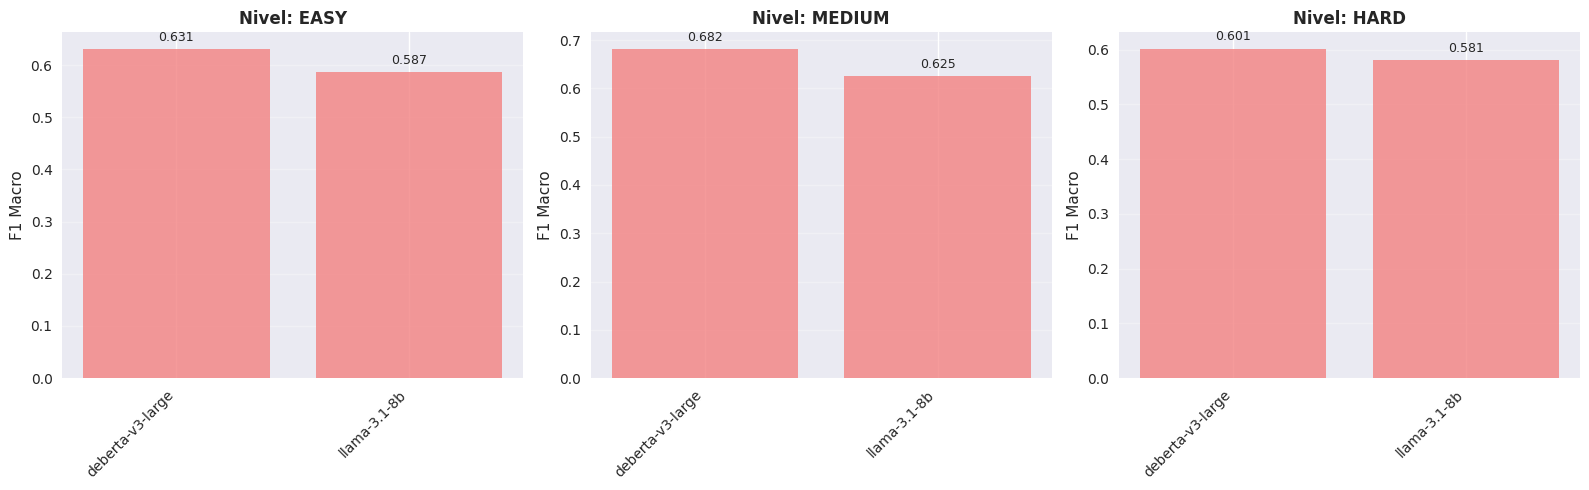

Grafico guardado en /home/eeguskiza/DEUSTO/multi-author-analysis/reports/12_f1_by_level.png


In [51]:
# Grafico de F1 Macro por nivel (3 subplots)
# Comparo como varia el rendimiento de cada modelo segun la dificultad

if 'results_by_level' in locals() and results_by_level:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    levels = ['easy', 'medium', 'hard']
    model_keys = sorted(results_by_level.keys())
    x = np.arange(len(model_keys))
    
    for idx, level in enumerate(levels):
        ax = axes[idx]
        
        # Extraigo F1 para este nivel
        f1_values = []
        for model_key in model_keys:
            f1 = results_by_level[model_key].get(level, {}).get('f1_macro', 0)
            f1_values.append(f1)
        
        # Creo barras con colores segun el modelo
        colors = ['#4ECDC4' if 'distilbert' in m else '#FF6B6B' if '0.6b' in m else '#95E1D3' if '1.7b' in m else '#F38181' for m in model_keys]
        bars = ax.bar(x, f1_values, color=colors, alpha=0.8)
        
        ax.set_ylabel('F1 Macro', fontsize=11)
        ax.set_title(f'Nivel: {level.upper()}', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(model_keys, rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        # Valores en barras
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / '12_f1_by_level.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Grafico guardado en {REPORTS_DIR / '12_f1_by_level.png'}")
else:
    print("No hay resultados por nivel para graficar.")

KeyError: 'eval_f1_macro'

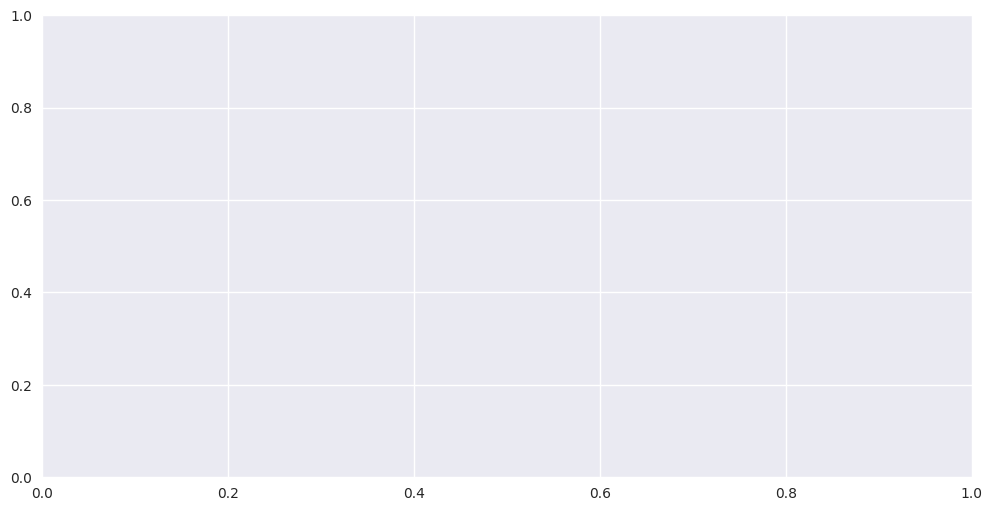

In [52]:
# Grafico de comparacion: F1 Macro agregado vs por nivel
# Muestra como varia el rendimiento de cada modelo en los diferentes niveles

if loaded_models and 'results_by_level' in locals() and results_by_level:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    model_keys = sorted(loaded_models.keys())
    x = np.arange(len(model_keys))
    width = 0.2
    
    # Extraigo F1 agregado y por nivel para cada modelo
    f1_aggregated = [loaded_models[m]['eval_metrics']['eval_f1_macro'] for m in model_keys]
    f1_easy = [results_by_level.get(m, {}).get('easy', {}).get('f1_macro', 0) for m in model_keys]
    f1_medium = [results_by_level.get(m, {}).get('medium', {}).get('f1_macro', 0) for m in model_keys]
    f1_hard = [results_by_level.get(m, {}).get('hard', {}).get('f1_macro', 0) for m in model_keys]
    
    # Creo barras agrupadas
    ax.bar(x - width*1.5, f1_aggregated, width, label='Agregado', color='#95E1D3', alpha=0.9)
    ax.bar(x - width*0.5, f1_easy, width, label='Easy', color='#4ECDC4', alpha=0.9)
    ax.bar(x + width*0.5, f1_medium, width, label='Medium', color='#F38181', alpha=0.9)
    ax.bar(x + width*1.5, f1_hard, width, label='Hard', color='#FF6B6B', alpha=0.9)
    
    ax.set_ylabel('F1 Macro', fontsize=12)
    ax.set_title('Comparacion F1 Macro: Agregado vs Por Nivel', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_keys, rotation=45, ha='right')
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / '12_f1_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Grafico guardado en {REPORTS_DIR / '12_f1_comparison.png'}")
else:
    print("No hay resultados completos para graficar.")

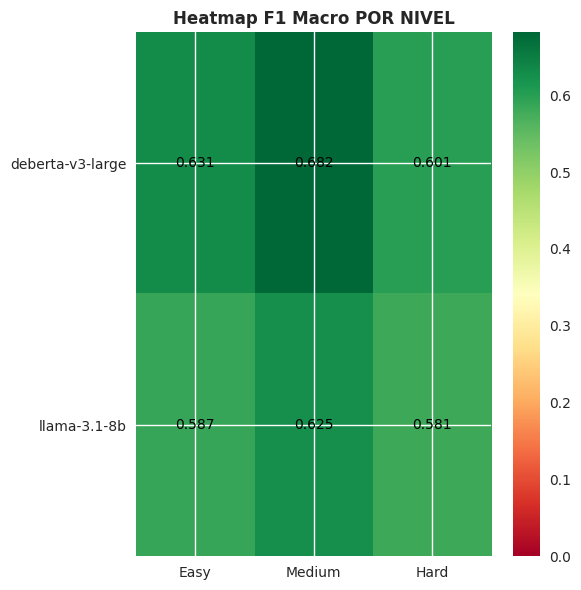

Heatmap guardado en /home/eeguskiza/DEUSTO/multi-author-analysis/reports/12_f1_heatmap_by_level.png


In [25]:
# Heatmap de F1 por nivel
# Visualizacion compacta de todos los modelos y niveles

if 'results_by_level' in locals() and results_by_level:
    f1_by_level_data = []
    model_labels = []
    
    for model_key in sorted(results_by_level.keys()):
        model_labels.append(model_key)
        levels_data = results_by_level[model_key]
        f1_by_level_data.append([
            levels_data.get('easy', {}).get('f1_macro', 0),
            levels_data.get('medium', {}).get('f1_macro', 0),
            levels_data.get('hard', {}).get('f1_macro', 0),
        ])
    
    f1_level_df = pd.DataFrame(
        f1_by_level_data,
        index=model_labels,
        columns=['Easy', 'Medium', 'Hard']
    )
    
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(f1_level_df.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=max(0.5, f1_level_df.values.max()))
    
    ax.set_xticks(np.arange(len(f1_level_df.columns)))
    ax.set_yticks(np.arange(len(f1_level_df.index)))
    ax.set_xticklabels(f1_level_df.columns)
    ax.set_yticklabels(f1_level_df.index)
    
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
    
    # Anadir valores en cada celda
    for i in range(len(f1_level_df.index)):
        for j in range(len(f1_level_df.columns)):
            text = ax.text(j, i, f'{f1_level_df.values[i, j]:.3f}',
                          ha="center", va="center", color="black", fontsize=10)
    
    ax.set_title('Heatmap F1 Macro POR NIVEL', fontweight='bold', fontsize=12)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / '12_f1_heatmap_by_level.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Heatmap guardado en {REPORTS_DIR / '12_f1_heatmap_by_level.png'}")
else:
    print("No hay resultados por nivel para crear heatmap.")

## 11. Comparacion con E3 e ICL

In [26]:
# Comparacion completa: Fine-tuning vs E3 vs ICL
# Esta es una comparacion preliminar - la comparacion completa va en el notebook 13

if loaded_models:
    print("\n" + "="*70)
    print("COMPARACION: Fine-tuning vs E3 vs ICL")
    print("="*70)
    print(f"\n{'Modelo':<30} {'F1 Macro':>10} {'Paradigma':>20}")
    print("-" * 70)
    
    # Modelos de referencia
    print(f"{'bert_cnn (E3 frozen)':<30} {'0.707':>10} {'Frozen+CNN':>20}")
    print(f"{'bert_lstm (E3 frozen)':<30} {'0.685':>10} {'Frozen+LSTM':>20}")
    print(f"{'qwen3:1.7b ICL (5-shot)':<30} {'0.383':>10} {'Zero-shot ICL':>20}")
    
    print("-" * 70)
    
    # Modelos fine-tuned ordenados por F1
    for model_key in sorted(loaded_models.keys(), key=lambda k: loaded_models[k]['eval_metrics']['eval_f1_macro'], reverse=True):
        result = loaded_models[model_key]
        f1 = result['eval_metrics']['eval_f1_macro']
        tecnica = 'QLoRA' if result['config'].get('use_qlora') else 'Full FT'
        print(f"{model_key + ' (fine-tuned)':<30} {f1:>10.3f} {tecnica:>20}")
    
    print("="*70)
    
    print("\nNOTAS:")
    print("  - E3: Frozen BERT + clasificador entrenado (33,858 val examples)")
    print("  - ICL: Zero-shot con 5 ejemplos (500 val examples)")
    print(f"  - Fine-tuning: End-to-end ({len(val_dataset):,} val examples)")
    print("  - Comparacion completa con analisis estadistico en notebook 13")
    
else:
    print("No hay resultados todavia. Ejecuta las celdas de entrenamiento primero.")


COMPARACION: Fine-tuning vs E3 vs ICL

Modelo                           F1 Macro            Paradigma
----------------------------------------------------------------------
bert_cnn (E3 frozen)                0.707           Frozen+CNN
bert_lstm (E3 frozen)               0.685          Frozen+LSTM
qwen3:1.7b ICL (5-shot)             0.383        Zero-shot ICL
----------------------------------------------------------------------


KeyError: 'eval_metrics'

## 12. Guardar Resultados Finales

In [ ]:
# Guardo las metricas finales: agregadas + por nivel
# Estos resultados se usaran en el notebook 13 para comparacion completa

if loaded_models:
    # Construir diccionario con metricas completas
    final_metrics = {}
    for model_key, result in loaded_models.items():
        final_metrics[model_key] = {
            'eval_metrics_aggregated': result['eval_metrics'],
            'eval_metrics_by_level': results_by_level.get(model_key, {}),
            'config': result['config'],
            'train_loss': result['train_loss'],
        }

    # Anadir metadatos del experimento
    final_metrics['_metadata'] = {
        'n_train': len(train_dataset),
        'n_val': len(val_dataset),
        'seed': SEED,
        'max_length': MAX_LENGTH,
        'val_distribution_by_level': {
            level: len([x for x in val_dataset if x['level'] == level])
            for level in ['easy', 'medium', 'hard']
        },
        'note': 'Fine-tuning experiments with full training and QLoRA. Includes aggregated and level-based metrics.'
    }

    # Guardar en JSON
    with open(REPORTS_DIR / "12_finetuning_metrics_final.json", "w") as f:
        json.dump(final_metrics, f, indent=2, default=str)

    print("="*70)
    print("RESULTADOS FINALES GUARDADOS")
    print("="*70)
    print(f"\nMetricas guardadas en {REPORTS_DIR / '12_finetuning_metrics_final.json'}")
    print(f"\nCheckpoints guardados en {CHECKPOINTS_DIR}")
    
    # Listar checkpoints guardados
    print("\nCheckpoints disponibles:")
    for model_key in loaded_models.keys():
        checkpoint_path = CHECKPOINTS_DIR / model_key / "best_model"
        if checkpoint_path.exists():
            # Calcular tamano del checkpoint
            size = sum(f.stat().st_size for f in checkpoint_path.rglob('*') if f.is_file())
            print(f"  - {model_key}: {size / 1e6:.1f} MB")
    
    print("\nProcede al notebook 13 para comparacion completa y analisis estadistico.")
    print("="*70)
    
else:
    print("No hay resultados para guardar. Ejecuta las celdas de entrenamiento primero.")